✅ Dataset berhasil dibaca!
📄 5 baris pertama dataset:
   Year Month  Total Number of Calls  Total Number of Doctors Consultancy  \
0  2025   Feb                 155200                                98964   
1  2025   Jan                 130982                                87815   
2  2024   Dec                 133725                                86832   
3  2024   Nov                 153698                                93710   
4  2024   Oct                 214604                               108207   

   Number of Total Health Information  Number of Total Ambulance Information  \
0                                3777                                   5773   
1                                3217                                   4179   
2                                3634                                   3735   
3                                3010                                   4421   
4                                6307                                   5792   

  

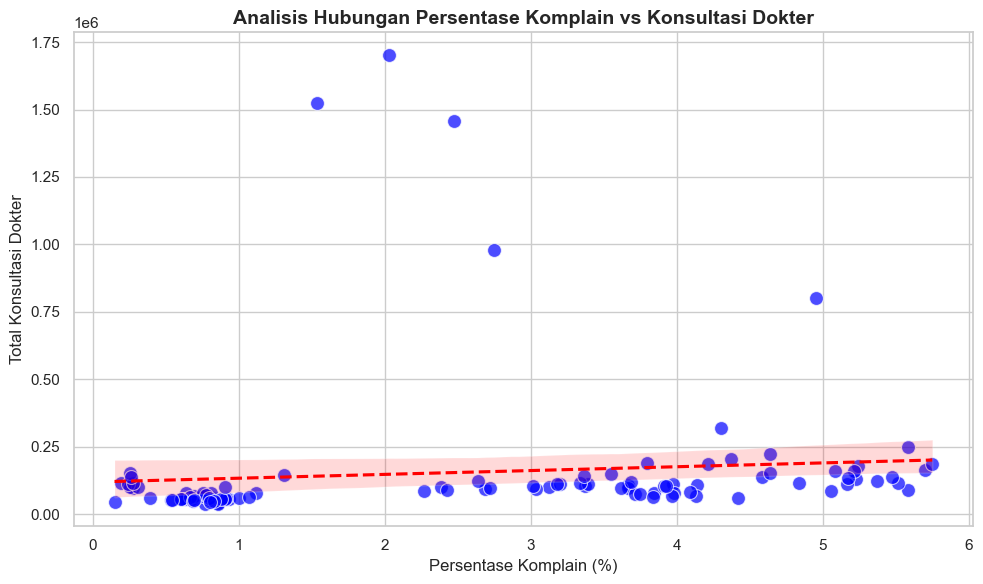

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. MENDEFINISIKAN FUNGSI UNTUK MEMBACA DATASET

def read_dataset(file_path):
    try:
        # Membaca file CSV
        df = pd.read_csv(file_path) 
        print("✅ Dataset berhasil dibaca!")
        print("📄 5 baris pertama dataset:")
        print(df.head())
        print("\n" + "="*50 + "\n")
        return df  # Mengembalikan objek DataFrame agar bisa dipakai di luar fungsi
    except FileNotFoundError:
        print(f"❌ Kesalahan: File di '{file_path}' tidak ditemukan.")
        print("Silakan periksa kembali folder atau nama file Anda.")
        return None
    except pd.errors.EmptyDataError:
        print("❌ Kesalahan: File tersebut kosong.")
        return None
    except Exception as e:
        print("❌ Terjadi kesalahan lain saat membaca file:", e)
        return None


# 2. PROSES MEMBACA FILE & PERHITUNGAN

path_file = r'C:/laprak/alprog/Kelas G_Fixed Call Report.csv'

# Panggil fungsi dan simpan hasilnya ke variabel df
df = read_dataset(path_file)

# Pastikan variabel df TIDAK bernilai None sebelum melakukan perhitungan
if df is not None:
    # Menghitung persentase kontribusi panggilan komplain
    df['Complaint_Percentage'] = (df['Number of Total Complaints'] / df['Total Number of Calls']) * 100
    
    print("✅ Kolom 'Complaint_Percentage' berhasil dihitung!")
    print("📄 Hasil beberapa kolom pilihan:")
    # Menampilkan hasil kolom baru bersandingan dengan total konsultasi dokter
    print(df[['Year', 'Month', 'Complaint_Percentage', 'Total Number of Doctors Consultancy']].head())
    
    
    # 3. VISUALISASI SCATTER PLOT
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # Membuat Scatter Plot
    sns.scatterplot(
        data=df, 
        x='Complaint_Percentage', 
        y='Total Number of Doctors Consultancy', 
        s=100, 
        color='blue', 
        alpha=0.7
    )
    
    # Menambahkan garis tren linear untuk melihat hubungan

    sns.regplot(
        data=df, 
        x='Complaint_Percentage', 
        y='Total Number of Doctors Consultancy', 
        scatter=False, 
        color='red', 
        line_kws={'linestyle': '--'}  # PERBAIKAN DI SINI
    )
    
    # Judul dan Label Grafik
    plt.title('Analisis Hubungan Persentase Komplain vs Konsultasi Dokter', fontsize=14, fontweight='bold')
    plt.xlabel('Persentase Komplain (%)', fontsize=12)
    plt.ylabel('Total Konsultasi Dokter', fontsize=12)
    
    plt.tight_layout()
    plt.show()

else:
    print("🛑 Proses dihentikan karena dataset tidak termuat dengan benar.")
